In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()
url = os.environ["DATABASE_URL"].replace("postgresql://", "postgresql+psycopg://")
engine = create_engine(url, pool_pre_ping=True)

In [5]:
df = pd.read_sql("""
    WITH latest AS (
        SELECT DISTINCT ON (listing_id) listing_id, price, currency
        FROM listing_snapshots
        ORDER BY listing_id, captured_at DESC
    )
    SELECT l.neighborhood,
           COUNT(*) AS n,
           ROUND(percentile_cont(0.5) WITHIN GROUP (ORDER BY s.price / l.covered_m2)) AS median_usd_m2,
           ROUND(percentile_cont(0.5) WITHIN GROUP (ORDER BY s.price))                AS median_price,
           ROUND(percentile_cont(0.5) WITHIN GROUP (ORDER BY l.covered_m2))           AS median_m2,
           mode() WITHIN GROUP (ORDER BY l.ambientes)                                 AS mode_amb
    FROM listings l
    JOIN latest s ON s.listing_id = l.id
    WHERE s.currency = 'USD' AND l.covered_m2 > 0
      AND s.price IS NOT NULL AND l.neighborhood IS NOT NULL
    GROUP BY l.neighborhood
    HAVING COUNT(*) >= 10
    ORDER BY median_usd_m2 DESC
""", engine)

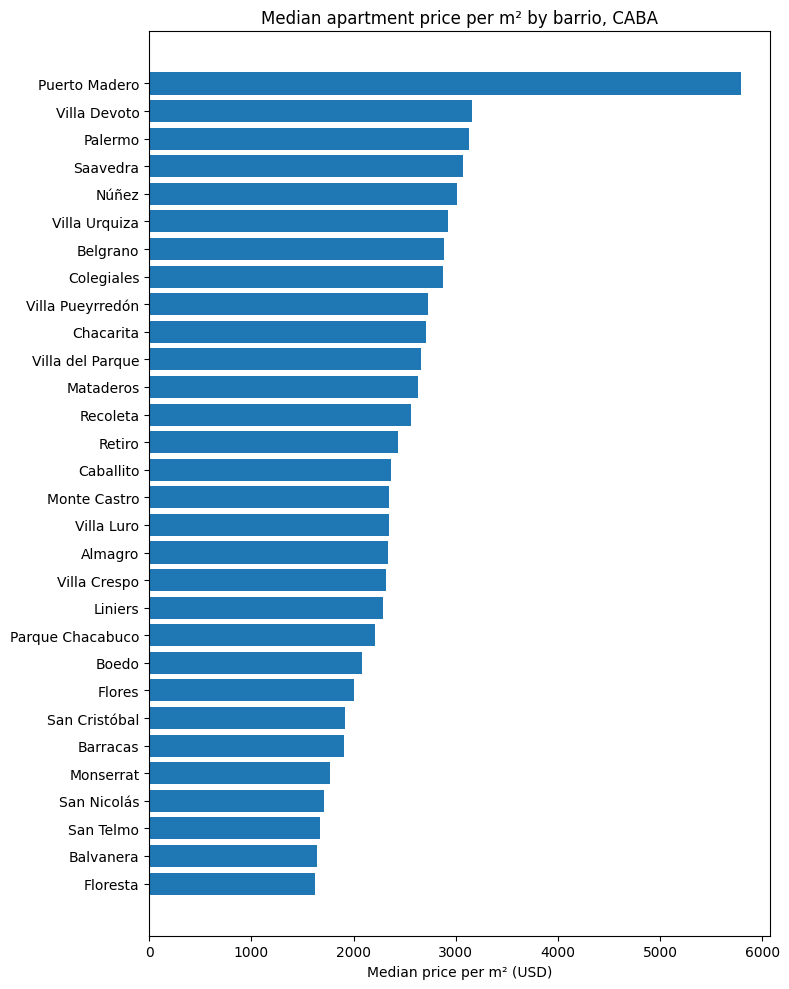

In [16]:
df_sorted = df.sort_values("median_usd_m2", ascending = True)

fig, ax = plt.subplots(figsize =(8, 10))

ax.barh(df_sorted["neighborhood"], df_sorted["median_usd_m2"])  

ax.set_xlabel("Median price per m² (USD)")
ax.set_title("Median apartment price per m² by barrio, CABA")

plt.tight_layout()
fig.savefig("charts/price_per_m2_by_barrio.png", dpi=150, bbox_inches="tight")

plt.show()

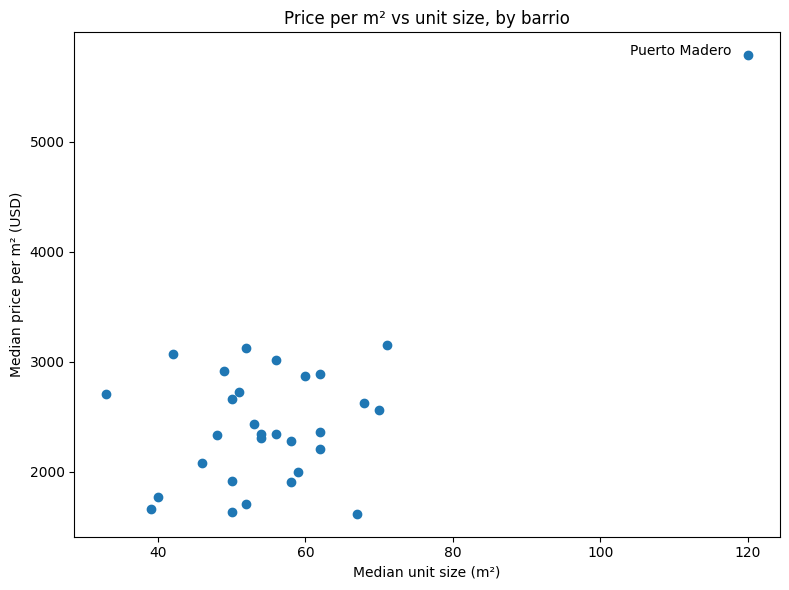

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(df["median_m2"], df["median_usd_m2"])

ax.set_xlabel("Median unit size (m²)")
ax.set_ylabel("Median price per m² (USD)")
ax.set_title("Price per m² vs unit size, by barrio")

plt.tight_layout()

pm = df[df["neighborhood"] == "Puerto Madero"].iloc[0]
ax.annotate("Puerto Madero", xy=(pm["median_m2"], pm["median_usd_m2"]),
            xytext=(pm["median_m2"] - 16, pm["median_usd_m2"]))

fig.savefig("charts/price_per_m2_vs_size.png", dpi=150, bbox_inches="tight")

plt.show()

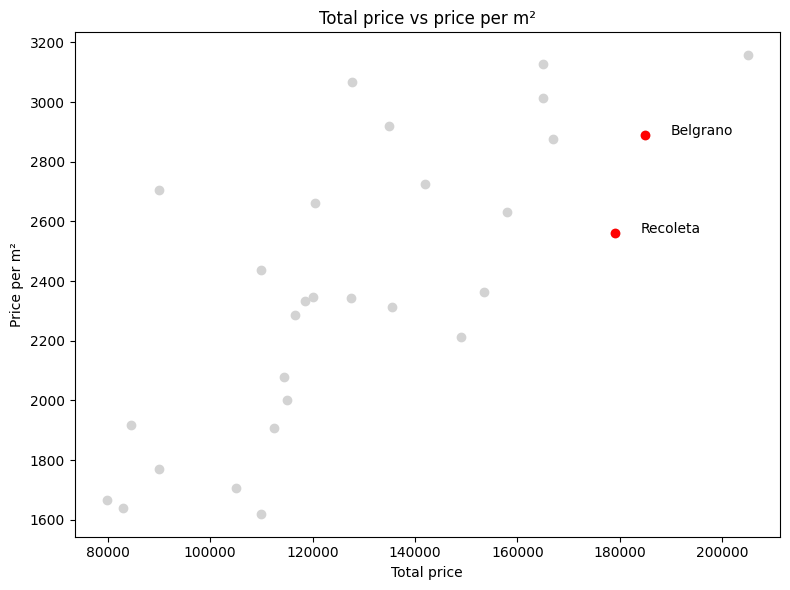

In [27]:
# PM tops both measures and its scale would squash the rest. Note in text.
plot_df = df[df["neighborhood"] != "Puerto Madero"]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(plot_df["median_price"], plot_df["median_usd_m2"], color="lightgrey")

for name in ["Recoleta", "Belgrano"]:
    row = plot_df[plot_df["neighborhood"] == name].iloc[0]
    ax.scatter(row["median_price"], row["median_usd_m2"], color="red")    
    ax.annotate(name, xy=(row["median_price"], row["median_usd_m2"]),
                xytext=(row["median_price"] + 5000, row["median_usd_m2"]))          

ax.set_xlabel("Total price")
ax.set_ylabel("Price per m²")
ax.set_title("Total price vs price per m²")
plt.tight_layout()
fig.savefig("charts/rank_divergence.png", dpi=150, bbox_inches="tight")
plt.show()